# Supplementary Analysis

In [56]:
# imports 
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import xarray as xr

from scipy.signal import sosfiltfilt, butter, sosfilt
from scipy.signal import welch
from scipy.stats import entropy, skew, kurtosis
os.environ['KERAS_BACKEND'] = 'torch'
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import torch
import keras
from meegkit import dss
from scipy.signal import butter, sosfiltfilt

import mne
from mne.time_frequency import psd_array_welch
from src.EEGModalNet.models.WGAN_v0 import WGAN_GP_V0
from src.EEGModalNet.preprocessing.preprocessing import preprocess_data


# helper functions
def segment_data(x, time_dim):
    return torch.tensor(x.copy()).unfold(2, time_dim, time_dim).permute(0, 2, 3, 1).flatten(0, 1)

def reverse_segmentation(x, n_subjects):
    return x.unflatten(0, (n_subjects, -1)).flatten(1, 2).permute(0, 2, 1)

def generate_data(model, x, sub, pos, latent_dim=128, use_random_sub=False, apply_sub_layer=False, use_global_mean_std=False):
    B, T, C = x.shape
    l = len(x)
    x_gen = torch.zeros((B, T, C))
    bs = 128
    random_sub = keras.random.randint(sub.shape, 0, sub.max(), dtype=torch.int64)

    if use_random_sub:
        for i in range(int(l/bs)):
            if use_global_mean_std:
                x_mean, x_std = -4.3159e-06, 0.4515
            else:
                x_mean, x_std = x[i*bs:(i+1)*bs].mean(), x[i*bs:(i+1)*bs].std()
            x_gen[i*bs:(i+1)*bs] = model.generator((keras.random.normal((bs, latent_dim), mean=x_mean, stddev=x_std),
                                                    random_sub[i*bs:(i+1)*bs].to('mps'),
                                                    pos[:bs].to('mps'))).cpu().detach()
    else:
        for i in range(int(l/bs)):
            if use_global_mean_std:
                x_mean, x_std = -4.3159e-06, 0.4515
            else:
                x_mean, x_std = x[i*bs:(i+1)*bs].mean(), x[i*bs:(i+1)*bs].std()

            x_gen[i*bs:(i+1)*bs] = model.generator((keras.random.normal((bs, latent_dim), mean=x_mean, stddev=x_std),
                                                    sub[i*bs:(i+1)*bs].to('mps'),
                                                    pos[:bs].to('mps'))).cpu().detach()
    # fill in the rest
    tr_sh = (x_gen.shape[0]//bs)*bs
    if tr_sh < B:
        res = B - tr_sh
        x_gen[-res:] = model.generator((keras.random.normal((res, 128), mean=x_mean, stddev=x_std),
                                                sub[-res:].to('mps'),
                                                pos[-res:].to('mps'))).cpu().detach()
    
    # use subject layer in data generation
    if apply_sub_layer:
        print('applying the subject layer...')
        if use_random_sub:
            x_gen = model.generator.layers[0].module(x_gen.to('mps'), random_sub.to('mps')).cpu().detach()
        else:
            x_gen = model.generator.layers[0].module(x_gen.to('mps'), sub.to('mps')).cpu().detach()

    return x_gen

def plot_psd_multi_channel(x, channels, ax, n_subjects=202, fmin=1, fmax=50, n_fft=512, label='real', db=True, color='blue',
                           reverse_first=True):
    if reverse_first:
        x = reverse_segmentation(x, n_subjects)
    else:
        x = x.permute(0, 2, 1)
    psd, freq = mne.time_frequency.psd_array_welch(x.numpy(), sfreq=128, fmin=fmin, fmax=fmax, n_fft=n_fft, verbose=False)
    if db:
        psd = 10*np.log10(psd)
    for i, c in enumerate(range(len(channels))):
        psd_ = psd[:, c, :]
        ax[i//4, i%4].plot(freq, psd_.mean(0), label=label, linewidth=2, color=color)
        ax[i//4, i%4].fill_between(freq, psd_.mean(0) - psd_.std(0), psd_.mean(0) + psd_.std(0), alpha=0.4, color=color)
        ax[i//4, i%4].set_title(f'Channel {channels[c]}', color='blue', fontsize=14, loc='left')
        ax[i//4, i%4].set_xlim([0.7, fmax])

def plot_time_domain(x, x_gen, time_dim, channels, ax, ch=0):
    x, x_gen = x[:, ch, :time_dim], x_gen[:, ch, :time_dim]
    real_data_avg = x.mean(0)
    fake_data_avg = x_gen.mean(0)
    ax.plot(fake_data_avg, label="Generated", color='orangered')
    ax.plot(real_data_avg, label="Real", color='navy', alpha=0.5)

    ax.fill_between(np.arange(time_dim),
                    real_data_avg - x.std(axis=0),
                    real_data_avg + x.std(axis=0),
                    alpha=0.4, color='navy')
    
    ax.fill_between(np.arange(time_dim),
            fake_data_avg - x_gen.std(axis=0),
            fake_data_avg + x_gen.std(axis=0),
            alpha=0.4, color='orangered')

    ax.set_title(f'Channel {channels[ch]}', fontsize=14, color='blue', loc='left')
    ax.set_xlim([0, time_dim])


def plot_psd_individual_subjects(reversed_x, channels, ax, n_sub_plotted=2, fmin=1, fmax=60, n_fft=512, color='blue'):
    psd, freq = mne.time_frequency.psd_array_welch(reversed_x[:n_sub_plotted], sfreq=128, fmin=fmin, fmax=fmax, n_fft=n_fft, verbose=False)
    psd = 10*np.log10(psd)
    for n in range(n_sub_plotted):
        for i, c in enumerate(range(len(channels))):
            psd_ = psd[n, c, :]
            ax[i//4, i%4].plot(freq, psd_, label=f'subject {n}', linewidth=2)
            ax[i//4, i%4].set_title(f'Channel {channels[c]}', color='blue', fontsize=14, loc='left')
            ax[i//4, i%4].set_xlim([0.7, fmax])

def calculate_psd_different_methods(x, x_gen, n_subjects, psd_method='reorder_first'):

    if psd_method == 'reverse_first':
        psd, freq = psd_array_welch(reverse_segmentation(x, n_subjects).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(reverse_segmentation(x_gen, n_subjects).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)

    if psd_method == 'flat_first':
        psd, freq = psd_array_welch(x.flatten(0, 1).permute(1, 0).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(x_gen.flatten(0, 1).permute(1, 0).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)

    if psd_method == 'reorder_first':
        psd, freq = psd_array_welch(x.permute(0, 2, 1).numpy(), sfreq=128, fmin=1, fmax=50, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(x_gen.permute(0, 2, 1).numpy(), sfreq=128, fmin=1, fmax=50, n_fft=512, verbose=False)
    
    return psd, psd_gen, freq

def time_domain_features_multi_channel(x, axis=-1):  # x: (n_samples, n_channels, n_timepoints)
    mean = np.mean(x, axis=axis)
    std = np.std(x, axis=axis)
    skewness = skew(x, axis=axis)
    kurtosis_ = kurtosis(x, axis=axis)
    rms = np.sqrt(np.mean(x**2, axis=axis))
    return np.stack([mean, std, skewness, kurtosis_, rms], axis=-1)  # (n_samples, n_channels, n_features)

def hjorth_parameters_multi_channel(signal, axis=-1): 
    activity = np.var(signal, axis=axis)
    first_derivative = np.diff(signal, axis=axis)
    mobility = np.sqrt(np.var(first_derivative, axis=axis) / activity)
    second_derivative = np.diff(first_derivative, axis=axis)
    complexity = np.sqrt(np.var(second_derivative, axis=axis) / np.var(first_derivative, axis=axis)) / mobility
    return np.stack([activity, mobility, complexity], axis=-1)

def spectral_features_multi_channel(signal, fs=128, nperseg=512):
    f, Pxx = welch(signal, fs=fs, nperseg=nperseg, axis=-1)
    total_power = np.sum(Pxx, axis=-1)
    delta = np.sum(Pxx[:, :, (f >= 0.25) & (f < 4)], axis=-1) / total_power
    theta = np.sum(Pxx[:, :, (f >= 4) & (f < 8)], axis=-1) / total_power
    alpha = np.sum(Pxx[:, :, (f >= 8) & (f < 13)], axis=-1) / total_power
    beta = np.sum(Pxx[:, :, (f >= 13) & (f <= 30)], axis=-1) / total_power
    gamma = np.sum(Pxx[:, :, (f > 30) & (f <= 50)], axis=-1) / total_power
    pxx_entropy = entropy(Pxx, axis=-1)
    return np.stack([delta, theta, alpha, beta, gamma, pxx_entropy], axis=-1)

## DATA

In [31]:
# Data Parameters
FILTERING = True
PREPROCESSING = True
LINE_NOISE_REMOVAL = True
TIME_DIM = 512
N_SUBJECTS = 10
EEG_DATA_PATH = 'data/LEMON_data/EC_ch-8_sf-128.nc5'
CHANNELS = ['O1', 'O2', 'P1', 'P2', 'C1', 'C2', 'F1', 'F2']

# Model parameters
LATENT_DIM = 128

# PATHS
STAT_PATH = 'logs/5/20250605_7th.csv'
CHECKPOINTS_PATH = 'logs/5/20250605_7th_epoch_1280.model.keras'

# REAL DATA
xarray = xr.open_dataarray(EEG_DATA_PATH, engine='h5netcdf')

sub_id = np.random.randint(0, 202, N_SUBJECTS)
x = xarray.sel(subject=xarray.subject[sub_id], channel=CHANNELS)
x = x.to_numpy()

if PREPROCESSING:
    x = preprocess_data(x, sampling_rate=128)

if FILTERING:
    sos = butter(4, 0.5, btype='high', fs=128, output='sos')
    x = sosfiltfilt(sos, x, axis=-1)

if LINE_NOISE_REMOVAL:
    x, _ = dss.dss_line(x.T, fline=50, sfreq=128, nremove=1)
    x = x.T

x_input = segment_data(x, TIME_DIM) # TODO
sub = torch.tensor(np.arange(0, N_SUBJECTS).repeat(x_input.shape[0]//N_SUBJECTS)[:, np.newaxis])
pos = torch.tensor(xarray.ch_positions[None].repeat(x_input.shape[0], 0))
# data = {'x': x, 'sub': sub, 'pos': pos}

>>>>Corrected Mean: 1.0738652155537826e-05, Std: 7.65033180638878e-05, Max: 0.0009309873669414916, Min: -0.0012673985684311252
>>>>Scaled Mean: -0.06645837163775203, Std: 1.1168044254298808, Max: 6.863960446810946, Min: -24.970136582044503
>>>>Normalized Mean: -1.7763568394002505e-17, Std: 0.9999999999999997, Max: 7.729194922252416, Min: -7.301550994625709
>>>>Clamped Mean: -1.7763568394002505e-17, Std: 0.9999999999999997, Max: 7.729194922252416, Min: -7.301550994625709
Power of components removed by DSS: 0.02


### Fake Data

In [23]:
# FAKE DATA
model = WGAN_GP_V0(time_dim=512, feature_dim=len(CHANNELS),
                   latent_dim=LATENT_DIM, n_subjects=202,
                   use_sublayer_generator=True,
                   use_sublayer_critic=True,
                   use_channel_merger_g=False,
                   use_channel_merger_c=False,
                   interpolation='bilinear')

# load model and history
model.load_weights(CHECKPOINTS_PATH)

with torch.no_grad():
    x_gen = generate_data(model, x, sub, pos, latent_dim=LATENT_DIM, apply_sub_layer=False, use_random_sub=False,
                          use_global_mean_std=False)

In [ ]:
_, ax = plt.subplots(2, 4, figsize=(20, 8))
plot_psd_multi_channel(x, CHANNELS, ax, n_subjects=N_SUBJECTS, reverse_first=True)
plot_psd_multi_channel(x_gen, CHANNELS, ax, n_subjects=N_SUBJECTS, color='red', reverse_first=True)

## Metrics for features similarity
### frequency domain

In [59]:
psd, freq = psd_array_welch(x.permute(0, 2, 1).numpy(), sfreq=128, fmin=1, fmax=50, n_fft=512, verbose=False)
psd_gen, freq_gen = psd_array_welch(x_gen.permute(0, 2, 1).numpy(), sfreq=128, fmin=1, fmax=50, n_fft=512, verbose=False)


# correlation between real and fake psd
from scipy.stats import pearsonr, spearmanr
corr, _ = pearsonr(psd.mean(0), psd_gen.mean(0), axis=1)
r_s, _ = spearmanr(psd.mean(0), psd_gen.mean(0), axis=1)
print(r_s.mean(), corr.mean())

0.9935540357409693 0.9537142172429105


### Statistical features of the timeseries

In [60]:
signal_gen = x_gen.squeeze().numpy()
fids = {}
for j, func in enumerate([hjorth_parameters_multi_channel,
                          spectral_features_multi_channel,
                          time_domain_features_multi_channel]):

    real_f = func(x.permute(0, 2, 1).cpu().detach().numpy())
    gen_f = func(x_gen.permute(0, 2, 1).cpu().detach().numpy())
    print(f'Correlation on {func.__name__[:-14]}: {pearsonr(real_f, gen_f, axis=-1)[0].mean()}')  # TODO: consider standardizing the features before computing FID

Correlation on hjorth_parameters: 0.968508044957137
Correlation on spectral_features: 0.992035625203074
Correlation on time_domain_features: 0.4047944509933591


# Fréchet Distance between spectral properties

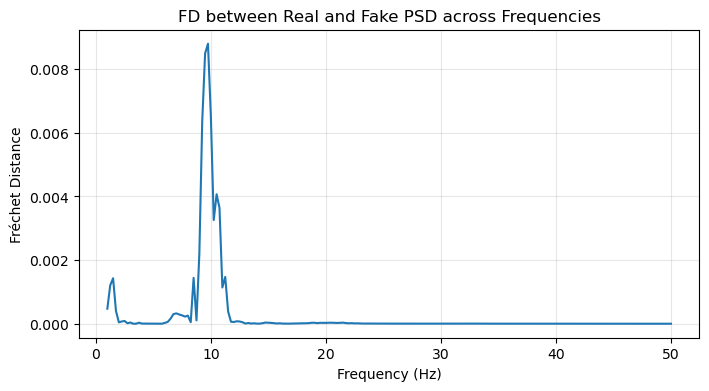

Average FD per band:
Delta : 0.0003
Theta : 0.0001
Alpha : 0.0024
Beta  : 0.0000
Gamma : 0.0000


In [ ]:
real_psd, fake_psd, freqs = calculate_psd_different_methods(x_input, x_gen, 10)

def frechet_distance(mu1, sigma1, mu2, sigma2):
    """Compute Fréchet Distance between two Gaussian distributions."""
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return np.sum((mu1 - mu2) ** 2) + np.trace(sigma1 + sigma2 - 2 * covmean)

# Compute per-frequency FD
n_freqs = real_psd.shape[-1]
fd_per_freq = np.zeros(n_freqs)

for i in range(n_freqs):
    r = real_psd[..., i].flatten()   # all samples × channels at frequency i
    f = fake_psd[..., i].flatten()
    mu_r, mu_f = np.mean(r), np.mean(f)
    sigma_r, sigma_f = np.cov(r), np.cov(f)
    fd_per_freq[i] = frechet_distance(np.array([mu_r]), np.array([[sigma_r]]),
                                      np.array([mu_f]), np.array([[sigma_f]]))

# plot FD curve
plt.figure(figsize=(8,4))
plt.plot(freqs, fd_per_freq, lw=1.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fréchet Distance')
plt.title('FD between Real and Fake PSD across Frequencies')
plt.grid(True, alpha=0.3)
plt.show()

# average FD within canonical EEG bands
bands = {
    'Delta': (1, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 45)
}

band_fd = {}
for band, (low, high) in bands.items():
    mask = (freqs >= low) & (freqs < high)
    band_fd[band] = np.mean(fd_per_freq[mask])

print("Average FD per band:")
for k, v in band_fd.items():
    print(f"{k:6s}: {v:.4f}")


In [ ]:
fig, ax = plt.subplots(2, 4, figsize=(20, 8))
# plot_psd_individual_subjects(reverse_segmentation(x_gen, 10)[:10].numpy(), CHANNELS, ax, n_sub_plotted=10)
plot_psd_individual_subjects(reverse_segmentation(x, 10).numpy(), CHANNELS, ax, n_sub_plotted=10)


fig, ax = plt.subplots(8, 1, figsize=(20, 16))
for i, ch in enumerate(range(len(CHANNELS))):
        plot_time_domain(reverse_segmentation(x, N_SUBJECTS), reverse_segmentation(x_gen, N_SUBJECTS), 4096, CHANNELS, ax[i], ch)

plt.legend()
plt.show()
